# 99_analyze — Black-Litterman 실험 결과 분석

본 노트북은 `final/results/*.pkl` 백테스트 결과를 분석하는 단일 진입점.

## 구조

```
[1] 빠른 진단              — Top 10 + 비교군 위치
[2] 거래비용 분석          — 슬롯별 turnover & TC
[3] J. Master Table 통합   — 슬롯 효과 + 매트릭스 + Top-N + 위기 + IR
[4] K. 레짐 안정성         — 3-레짐 sortino_ir/sharpe_ir Top 20 + Q 민감도
```

**모든 셀은 q=0.003 baseline만 사용** (mt/rt가 J1, K1에서 q 변형 제외 필터 적용).

셀별 해설: [`99_ANALYZE_GUIDE.md`](99_ANALYZE_GUIDE.md)

In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import platform
from pathlib import Path

warnings.filterwarnings('ignore')

if platform.system() == 'Darwin':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'Arial Unicode MS', 'DejaVu Sans']
elif platform.system() == 'Windows':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'Arial Unicode MS', 'DejaVu Sans']
else:
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'Noto Sans CJK KR', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

RESULTS_DIR = Path.cwd() / 'results'
OUT_DIR     = Path.cwd() / 'outputs' / '99_analyze'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 결과 로드 ──────────────────────────────────────────────────
loaded = {}
for pkl in sorted(RESULTS_DIR.glob('*.pkl')):
    with open(pkl, 'rb') as f:
        loaded[pkl.stem] = pickle.load(f)

# ── rf 로드 ────────────────────────────────────────────────────
panel_rf = pd.read_csv(Path.cwd() / 'data' / 'monthly_panel.csv',
                       usecols=['date','ticker','rf_1m'], parse_dates=['date'])
rf = panel_rf.groupby('date')['rf_1m'].first()

spy_ret = loaded['baseline']['spy_ret'].dropna()

# ── 성과 계산 함수 ──────────────────────────────────────────────
def calc(name):
    r    = loaded[name]['ret'].dropna()
    rf_a = rf.reindex(r.index).fillna(0)
    exc  = r - rf_a
    ann  = exc.mean() * 12
    vol  = r.std() * np.sqrt(12)
    sh   = ann / vol if vol > 0 else np.nan
    cum  = (1 + r).cumprod()
    mdd  = ((cum / cum.cummax()) - 1).min()
    dsd  = r[r < 0].std() * np.sqrt(12)
    sor  = ann / dsd if dsd > 0 else np.nan
    tot  = cum.iloc[-1] - 1
    cagr = r.mean() * 12
    return dict(sharpe=sh, cagr=cagr, vol=vol, mdd=mdd,
                sortino=sor, total=tot, ret=r, cum=cum)

# SPY 성과
def calc_spy():
    r    = spy_ret
    rf_a = rf.reindex(r.index).fillna(0)
    exc  = r - rf_a
    ann  = exc.mean() * 12
    vol  = r.std() * np.sqrt(12)
    sh   = ann / vol
    cum  = (1 + r).cumprod()
    mdd  = ((cum / cum.cummax()) - 1).min()
    return dict(sharpe=sh, cagr=r.mean()*12, vol=vol, mdd=mdd, total=cum.iloc[-1]-1, cum=cum)

print(f'로드 완료: {len(loaded)}개 실험')
print(f'기간: {loaded["baseline"]["ret"].index[0].date()} ~ {loaded["baseline"]["ret"].index[-1].date()}')


로드 완료: 243개 실험
기간: 2010-01-31 ~ 2024-12-31


## L14. 3-SET 통합 비교 — 논문 구조 고정 + 한 슬롯만 변경

**Anchor**: q_mode = `ff3_paper_mean`, omega = `ff3_paper` (논문 충실)

- **SET 1 (Q only)**: prior=mcap, p_weight=mcap 고정 → q_mode 6종 변경 (6 pair)
- **SET 2 (P only)**: prior=mcap, q=fpm 고정 → p_weight {mcap, eq, rp} (3 pair)
- **SET 3 (Prior only)**: p_weight=mcap, q=fpm 고정 → prior {mcap, eq, rp} (3 pair)
- **SET 4 (Omega only)**: prior=mcap, p_w=mcap, q=fpm 고정 → omega {pap, he, rms} (3 pair)

각 pair = (LSTM, ANN). LSTM 우위가 어떤 슬롯에서 견고한지 확인.

In [ ]:
# ── L14. 3-SET 통합 비교 (paper-faithful Q anchor) ──
import math, pickle
CUTOFF = '2023-12-31'  # 평가 컷오프

def _full_metrics(ret, rf, mkt):
    r = ret.dropna()
    rfa = rf.reindex(r.index).fillna(0); mka = mkt.reindex(r.index).fillna(0)
    exc = r - rfa; mexc = mka - rfa
    vol = r.std() * np.sqrt(12)
    cagr = (1 + r).prod() ** (12 / len(r)) - 1
    sh = float(exc.mean() * 12 / vol) if vol > 0 else np.nan
    dn = r[r < 0].std() * np.sqrt(12)
    so = float(exc.mean() * 12 / dn) if (dn and dn > 0) else np.nan
    cum = (1 + r).cumprod()
    mdd = float((cum / cum.cummax() - 1).min())
    if mexc.var() > 0:
        beta = float(np.cov(exc, mexc, ddof=0)[0,1] / mexc.var())
        alpha = float((exc.mean() - beta * mexc.mean()) * 12)
    else:
        beta = alpha = np.nan
    return dict(Sharpe=sh, Sortino=so, CAGR=cagr, Vol=vol, MDD=mdd, Beta=beta, Alpha=alpha)

def _get(name):
    p = RESULTS_DIR / f'{name}.pkl'
    if not p.exists(): return None
    with open(p, 'rb') as f:
        return _full_metrics(pickle.load(f)['ret'], rf, spy_ret)

# ── SET 정의 ─────────────────────────────────────────────
# 각 entry: (label, lstm_name, ann_name)
SETS = {
    'SET 1: Q only (prior=mcap, p_w=mcap)': [
        ('q=fix',     'mat_mcap_mcap_fix_pap', 'mat_mcap_mcap_fix_pap_ann'),
        ('q=lam',     'mat_mcap_mcap_lam_pap', 'mat_mcap_mcap_lam_pap_ann'),
        ('q=raw_lam', 'mat_mcap_mcap_raw_pap', 'mat_mcap_mcap_raw_pap_ann'),
        ('q=inv_lam', 'mat_mcap_mcap_inv_pap', 'mat_mcap_mcap_inv_pap_ann'),
        ('q=vsp',     'mat_mcap_mcap_vsp_pap', 'mat_mcap_mcap_vsp_pap_ann'),
        ('q=fpm★',    'paper_lstm',            'paper_ann'),
    ],
    'SET 2: P only (prior=mcap, q=fpm)': [
        ('p_w=mcap★', 'paper_lstm',            'paper_ann'),
        ('p_w=eq',    'mat_mcap_eq_fpm_pap',   'mat_mcap_eq_fpm_pap_ann'),
        ('p_w=rp',    'mat_mcap_rp_fpm_pap',   'mat_mcap_rp_fpm_pap_ann'),
    ],
    'SET 3: Prior only (p_w=mcap, q=fpm)': [
        ('prior=mcap★', 'paper_lstm',          'paper_ann'),
        ('prior=eq',    'mat_eq_mcap_fpm_pap', 'mat_eq_mcap_fpm_pap_ann'),
        ('prior=rp',    'mat_rp_mcap_fpm_pap', 'mat_rp_mcap_fpm_pap_ann'),
    ],
    'SET 4: Omega only (prior=mcap, p_w=mcap, q=fpm)': [
        ('omega=pap★', 'paper_lstm',                 'paper_ann'),
        ('omega=he',   'mat_mcap_mcap_fpm_he',       'mat_mcap_mcap_fpm_he_ann'),
        ('omega=rms',  'mat_mcap_mcap_fpm_rms',      'mat_mcap_mcap_fpm_rms_ann'),
    ],
}

# ── 결과 수집 ─────────────────────────────────────────────
all_rows = []
for set_name, pairs in SETS.items():
    for label, lname, aname in pairs:
        L = _get(lname); A = _get(aname)
        if not L or not A:
            print(f'  ⚠ missing: {lname} or {aname}')
            continue
        all_rows.append({
            'SET': set_name.split(':')[0],
            'config': label,
            'L_Sharpe': L['Sharpe'], 'A_Sharpe': A['Sharpe'], 'd_Sharpe': L['Sharpe']-A['Sharpe'],
            'L_Sortino': L['Sortino'], 'A_Sortino': A['Sortino'], 'd_Sortino': L['Sortino']-A['Sortino'],
            'L_CAGR': L['CAGR'], 'A_CAGR': A['CAGR'], 'd_CAGR': L['CAGR']-A['CAGR'],
            'L_Alpha': L['Alpha'], 'A_Alpha': A['Alpha'], 'd_Alpha': L['Alpha']-A['Alpha'],
            'L_MDD': L['MDD'], 'A_MDD': A['MDD'], 'd_MDD': L['MDD']-A['MDD'],
            'win': 'LSTM' if L['Sharpe'] > A['Sharpe'] else 'ANN',
        })

cmp_df = pd.DataFrame(all_rows)

# ── SET별 요약 ─────────────────────────────────────────────
print('='*72)
print('■ SET별 LSTM 우위 요약 (paper-faithful Q anchor)')
print('='*72)
for set_id in cmp_df['SET'].unique():
    sub = cmp_df[cmp_df['SET'] == set_id]
    n = len(sub)
    wL = (sub['win'] == 'LSTM').sum()
    p_val = sum(math.comb(n,k) * 0.5**n for k in range(wL, n+1))
    print(f'[{set_id}] n={n}쌍, LSTM 승={wL}/{n}, Binomial p={p_val:.3f}')
    print(f'   평균 d_Sharpe  = {sub["d_Sharpe"].mean():+.4f}')
    print(f'   평균 d_Sortino = {sub["d_Sortino"].mean():+.4f}')
    print(f'   평균 d_CAGR    = {sub["d_CAGR"].mean():+.2%}')
    print(f'   평균 d_Alpha   = {sub["d_Alpha"].mean():+.2%}')
    print(f'   평균 d_MDD     = {sub["d_MDD"].mean():+.2%}  (양수=LSTM이 덜 빠짐)')

# 전체 요약
n = len(cmp_df)
wL = (cmp_df['win'] == 'LSTM').sum()
p_val = sum(math.comb(n,k) * 0.5**n for k in range(wL, n+1))
print()
print('='*72)
print(f'■ 전체 통합 ({n}쌍): LSTM 승={wL}/{n}, Binomial p={p_val:.3f}')
print('='*72)
print()

# ── 표 표시 (SET별 색상 묶음) ─────────────────────────────
display_df = cmp_df.set_index(['SET', 'config'])[[
    'L_Sharpe','A_Sharpe','d_Sharpe',
    'L_Sortino','A_Sortino','d_Sortino',
    'L_Alpha','A_Alpha','d_Alpha',
    'L_MDD','A_MDD','d_MDD',
    'win']]

def _hl_diff(v):
    if not isinstance(v, (int, float)) or pd.isna(v):
        return ''
    if v > 0:
        return 'background-color: #b8e0b8; color: black; font-weight: bold'
    elif v < 0:
        return 'background-color: #f4b6b6; color: black; font-weight: bold'
    return ''

styled = display_df.style.format({
    'L_Sharpe':'{:.3f}','A_Sharpe':'{:.3f}','d_Sharpe':'{:+.3f}',
    'L_Sortino':'{:.3f}','A_Sortino':'{:.3f}','d_Sortino':'{:+.3f}',
    'L_Alpha':'{:.2%}','A_Alpha':'{:.2%}','d_Alpha':'{:+.2%}',
    'L_MDD':'{:.2%}','A_MDD':'{:.2%}','d_MDD':'{:+.2%}',
}).map(_hl_diff, subset=['d_Sharpe','d_Sortino','d_Alpha','d_MDD'])

display(styled)


■ SET별 LSTM 우위 요약 (paper-faithful Q anchor)
[SET 1] n=6쌍, LSTM 승=1/6, Binomial p=0.984
   평균 d_Sharpe  = -0.0500
   평균 d_Sortino = -0.0822
   평균 d_CAGR    = -0.39%
   평균 d_Alpha   = -0.56%
   평균 d_MDD     = -2.34%  (양수=LSTM이 덜 빠짐)
[SET 2] n=3쌍, LSTM 승=2/3, Binomial p=0.500
   평균 d_Sharpe  = +0.0035
   평균 d_Sortino = -0.0723
   평균 d_CAGR    = +0.56%
   평균 d_Alpha   = -0.16%
   평균 d_MDD     = -2.16%  (양수=LSTM이 덜 빠짐)
[SET 3] n=3쌍, LSTM 승=0/3, Binomial p=1.000
   평균 d_Sharpe  = -0.1319
   평균 d_Sortino = -0.4311
   평균 d_CAGR    = -0.52%
   평균 d_Alpha   = -1.95%
   평균 d_MDD     = -9.05%  (양수=LSTM이 덜 빠짐)
[SET 4] n=3쌍, LSTM 승=0/3, Binomial p=1.000
   평균 d_Sharpe  = -0.0504
   평균 d_Sortino = -0.2247
   평균 d_CAGR    = +0.77%
   평균 d_Alpha   = -0.82%
   평균 d_MDD     = -4.05%  (양수=LSTM이 덜 빠짐)

■ 전체 통합 (15쌍): LSTM 승=3/15, Binomial p=0.996



## L15. SET 1~4 — 레짐별 LSTM vs ANN 통합 비교

3개 레짐 (R1_회복 / R2_확장 / R3_변동) × 15 pair (SET 1~4 전체).

**가설**: ANN의 paper-anchor 우위는 위기 포함 레짐 (R1·R3) 에 집중되어 있고, calm 레짐 (R2_확장) 에서는 LSTM이 슬롯 변형 전반에서 우위.

- SET 1: Q only (6 pair) — q_mode 변경
- SET 2: P only (3 pair) — p_weight 변경
- SET 3: Prior only (3 pair) — prior 변경
- SET 4: Omega only (3 pair) — omega_mode 변경

In [ ]:
# ── L15. SET 1~4 × 레짐별 LSTM vs ANN 통합 비교 ──
import pickle
from master_table import REGIMES as _REGIMES_orig
REGIMES = [(lbl, s, '2023-12-31' if lbl == 'R3_변동' else e) for lbl, s, e in _REGIMES_orig]
CUTOFF = '2023-12-31'  # 평가 컷오프

def _regime_metrics(name, s, e):
    p = RESULTS_DIR / f'{name}.pkl'
    if not p.exists(): return None
    with open(p, 'rb') as f:
        r = pickle.load(f)['ret'].dropna()
        r = r[r.index <= CUTOFF]
    sub = r[(r.index >= s) & (r.index <= e)]
    if len(sub) < 6: return None
    rfa = rf.reindex(sub.index).fillna(0); mka = spy_ret.reindex(sub.index).fillna(0)
    exc = sub - rfa; mexc = mka - rfa
    vol = sub.std() * np.sqrt(12)
    sh = float(exc.mean() * 12 / vol) if vol > 0 else np.nan
    dn = sub[sub < 0].std() * np.sqrt(12)
    so = float(exc.mean() * 12 / dn) if (dn and dn > 0) else np.nan
    cum = (1 + sub).cumprod()
    mdd = float((cum / cum.cummax() - 1).min())
    if mexc.var() > 0:
        beta = float(np.cov(exc, mexc, ddof=0)[0,1] / mexc.var())
        alpha = float((exc.mean() - beta * mexc.mean()) * 12)
    else:
        beta = alpha = np.nan
    return dict(Sharpe=sh, Sortino=so, MDD=mdd, Alpha=alpha)

# ── SET 정의 (L14 와 동일) ────────────────────────────────
SETS_L15 = {
    'SET1': [
        ('q=fix',     'mat_mcap_mcap_fix_pap', 'mat_mcap_mcap_fix_pap_ann'),
        ('q=lam',     'mat_mcap_mcap_lam_pap', 'mat_mcap_mcap_lam_pap_ann'),
        ('q=raw',     'mat_mcap_mcap_raw_pap', 'mat_mcap_mcap_raw_pap_ann'),
        ('q=inv',     'mat_mcap_mcap_inv_pap', 'mat_mcap_mcap_inv_pap_ann'),
        ('q=vsp',     'mat_mcap_mcap_vsp_pap', 'mat_mcap_mcap_vsp_pap_ann'),
        ('q=fpm★',    'paper_lstm',            'paper_ann'),
    ],
    'SET2': [
        ('p_w=mcap★', 'paper_lstm',            'paper_ann'),
        ('p_w=eq',    'mat_mcap_eq_fpm_pap',   'mat_mcap_eq_fpm_pap_ann'),
        ('p_w=rp',    'mat_mcap_rp_fpm_pap',   'mat_mcap_rp_fpm_pap_ann'),
    ],
    'SET3': [
        ('prior=mcap★', 'paper_lstm',          'paper_ann'),
        ('prior=eq',    'mat_eq_mcap_fpm_pap', 'mat_eq_mcap_fpm_pap_ann'),
        ('prior=rp',    'mat_rp_mcap_fpm_pap', 'mat_rp_mcap_fpm_pap_ann'),
    ],
    'SET4': [
        ('omega=pap★', 'paper_lstm',                 'paper_ann'),
        ('omega=he',   'mat_mcap_mcap_fpm_he',       'mat_mcap_mcap_fpm_he_ann'),
        ('omega=rms',  'mat_mcap_mcap_fpm_rms',      'mat_mcap_mcap_fpm_rms_ann'),
    ],
}

# ── 모든 (레짐 × pair) 수집 ────────────────────────────────
all_rows = []
for set_id, pairs in SETS_L15.items():
    for label, L, A in pairs:
        for lbl, s, e in REGIMES:
            mL = _regime_metrics(L, s, e); mA = _regime_metrics(A, s, e)
            if mL is None or mA is None: continue
            all_rows.append({
                'SET': set_id, 'pair': label, 'regime': lbl,
                'L_Sh': mL['Sharpe'], 'A_Sh': mA['Sharpe'], 'd_Sh': mL['Sharpe']-mA['Sharpe'],
                'L_So': mL['Sortino'], 'A_So': mA['Sortino'], 'd_So': mL['Sortino']-mA['Sortino'],
                'L_MDD': mL['MDD'], 'A_MDD': mA['MDD'],
                'win': 'LSTM' if mL['Sharpe'] > mA['Sharpe'] else 'ANN',
            })

reg_df = pd.DataFrame(all_rows)

# ── (1) SET × 레짐 LSTM 승수 요약 ──────────────────────────
print('='*78)
print('■ SET × 레짐 LSTM 승수 (총 15 pair × 3 레짐 = 45)')
print('='*78)
print(f'{"":<8s}{"R1_회복":>14s}{"R2_확장":>14s}{"R3_변동":>14s}{"합계":>10s}')
print('-'*78)
for set_id in ['SET1','SET2','SET3','SET4']:
    sub_set = reg_df[reg_df['SET'] == set_id]
    n_pair = sub_set['pair'].nunique()
    cells = []
    total_w = 0
    for lbl, _, _ in REGIMES:
        sub = sub_set[sub_set['regime'] == lbl]
        wL = (sub['win']=='LSTM').sum()
        cells.append(f'{wL}/{n_pair}')
        total_w += wL
    print(f'{set_id:<8s}' + ''.join(f'{c:>14s}' for c in cells) + f'{total_w}/{n_pair*3:>5d}'.rjust(10))

# 레짐별 합계
print('-'*78)
total_per_regime = []
for lbl, _, _ in REGIMES:
    sub = reg_df[reg_df['regime'] == lbl]
    wL = (sub['win']=='LSTM').sum()
    total_per_regime.append(f'{wL}/{len(sub)}')
print(f'{"합계":<8s}' + ''.join(f'{c:>14s}' for c in total_per_regime) +
      f'{(reg_df["win"]=="LSTM").sum()}/{len(reg_df):>5d}'.rjust(10))
print('='*78)

# ── (2) 레짐별 평균 d_Sharpe / d_Sortino ─────────────────
print()
print('■ 레짐별 평균 LSTM 우위 (Sharpe / Sortino)')
print('-'*60)
for lbl, _, _ in REGIMES:
    for set_id in ['SET1','SET2','SET3','SET4']:
        sub = reg_df[(reg_df['regime']==lbl) & (reg_df['SET']==set_id)]
        if len(sub)==0: continue
        print(f'  [{lbl}] {set_id}: '
              f'mean d_Sh={sub["d_Sh"].mean():+.3f},  d_So={sub["d_So"].mean():+.3f}')
    print()

# ── (3) 풀 표 (45 행) ──────────────────────────────────────
display_df = reg_df.set_index(['SET','pair','regime'])[[
    'L_Sh','A_Sh','d_Sh','L_So','A_So','d_So','L_MDD','A_MDD','win'
]]

def _hl_diff(v):
    if not isinstance(v, (int, float)) or pd.isna(v):
        return ''
    if v > 0:
        return 'background-color: #b8e0b8; color: black; font-weight: bold'
    elif v < 0:
        return 'background-color: #f4b6b6; color: black; font-weight: bold'
    return ''

styled = display_df.style.format({
    'L_Sh':'{:.3f}','A_Sh':'{:.3f}','d_Sh':'{:+.3f}',
    'L_So':'{:.3f}','A_So':'{:.3f}','d_So':'{:+.3f}',
    'L_MDD':'{:.2%}','A_MDD':'{:.2%}',
}).map(_hl_diff, subset=['d_Sh','d_So'])

display(styled)


■ SET × 레짐 LSTM 승수 (총 15 pair × 3 레짐 = 45)
                 R1_회복         R2_확장         R3_변동        합계
------------------------------------------------------------------------------
SET1               0/6           2/6           5/6   7/   18
SET2               1/3           3/3           2/3   6/    9
SET3               0/3           3/3           0/3   3/    9
SET4               0/3           3/3           1/3   4/    9
------------------------------------------------------------------------------
합계                1/15         11/15          8/15  20/   45

■ 레짐별 평균 LSTM 우위 (Sharpe / Sortino)
------------------------------------------------------------
  [R1_회복] SET1: mean d_Sh=-0.245,  d_So=-0.282
  [R1_회복] SET2: mean d_Sh=-0.105,  d_So=-0.038
  [R1_회복] SET3: mean d_Sh=-0.303,  d_So=-0.414
  [R1_회복] SET4: mean d_Sh=-0.267,  d_So=-0.356

  [R2_확장] SET1: mean d_Sh=-0.087,  d_So=-0.225
  [R2_확장] SET2: mean d_Sh=+0.048,  d_So=-0.108
  [R2_확장] SET3: mean d_Sh=+0.093,  d_So=-0.120
  [R2

## L16. SET 5 — P×Q Matrix (P=eq/rp × 6 q_mode × LSTM/ANN)

**고정**: prior=mcap, omega=ff3_paper (paper anchor 부분 유지)
**변경**: p_weight ∈ {eq, rp} × q_mode ∈ {fix, lam, raw, inv, vsp, fpm} = 12 pair

**가설**: P=eq/rp 슬롯이 LSTM 우위 만든다는 SET 2 결과를 q_mode 다양하게 변경해도 일관되게 유지되는지, 그리고 R1 위기에서도 LSTM이 살아나는지 확인.

In [ ]:
# ── L16. SET 5 P×Q matrix — LSTM vs ANN ──
import math, pickle
from master_table import REGIMES as _REGIMES_orig
REGIMES = [(lbl, s, '2023-12-31' if lbl == 'R3_변동' else e) for lbl, s, e in _REGIMES_orig]
CUTOFF = '2023-12-31'  # 평가 컷오프

def _full_metrics(ret, exclude=None):
    r = ret.dropna()
    if exclude: r = r[~r.index.to_period('M').astype(str).isin(exclude)]
    rfa = rf.reindex(r.index).fillna(0); mka = spy_ret.reindex(r.index).fillna(0)
    exc = r - rfa; mexc = mka - rfa
    vol = r.std() * np.sqrt(12)
    sh = float(exc.mean() * 12 / vol) if vol > 0 else np.nan
    dn = r[r < 0].std() * np.sqrt(12)
    so = float(exc.mean() * 12 / dn) if (dn and dn > 0) else np.nan
    cum = (1 + r).cumprod()
    mdd = float((cum / cum.cummax() - 1).min())
    if mexc.var() > 0:
        beta = float(np.cov(exc, mexc, ddof=0)[0,1] / mexc.var())
        alpha = float((exc.mean() - beta * mexc.mean()) * 12)
    else:
        beta = alpha = np.nan
    return dict(Sharpe=sh, Sortino=so, MDD=mdd, Alpha=alpha)

def _regime_sh(name, s, e):
    p = RESULTS_DIR / f'{name}.pkl'
    if not p.exists(): return None
    with open(p, 'rb') as f:
        r = pickle.load(f)['ret'].dropna()
        r = r[r.index <= CUTOFF]
    sub = r[(r.index >= s) & (r.index <= e)]
    if len(sub) < 6: return None
    rfa = rf.reindex(sub.index).fillna(0)
    exc = sub - rfa
    vol = sub.std() * np.sqrt(12)
    return float(exc.mean() * 12 / vol) if vol > 0 else np.nan

def _get(name):
    p = RESULTS_DIR / f'{name}.pkl'
    if not p.exists(): return None
    with open(p, 'rb') as f:
        return _full_metrics(pickle.load(f)['ret'])

# ── Pair 정의: P=eq/rp × 6 q_modes ──────────────────────────
PAIRS_L16 = []
for pw in ['eq', 'rp']:
    for q in ['fix', 'lam', 'raw', 'inv', 'vsp', 'fpm']:
        L = f'mat_mcap_{pw}_{q}_pap'
        A = f'mat_mcap_{pw}_{q}_pap_ann'
        PAIRS_L16.append((f'P={pw} / Q={q}', L, A))

# ── 전체 기간 비교 ───────────────────────────────────────────
rows = []
for label, L, A in PAIRS_L16:
    mL = _get(L); mA = _get(A)
    if not mL or not mA:
        print(f'  ⚠ missing: {L} or {A}')
        continue
    rows.append({
        'pair': label,
        'L_Sh': mL['Sharpe'], 'A_Sh': mA['Sharpe'], 'd_Sh': mL['Sharpe']-mA['Sharpe'],
        'L_So': mL['Sortino'], 'A_So': mA['Sortino'], 'd_So': mL['Sortino']-mA['Sortino'],
        'L_Alp': mL['Alpha'], 'A_Alp': mA['Alpha'], 'd_Alp': mL['Alpha']-mA['Alpha'],
        'L_MDD': mL['MDD'], 'A_MDD': mA['MDD'], 'd_MDD': mL['MDD']-mA['MDD'],
        'win': 'LSTM' if mL['Sharpe'] > mA['Sharpe'] else 'ANN',
    })
df_full = pd.DataFrame(rows)

n = len(df_full); wL = (df_full['win'] == 'LSTM').sum()
p_val = sum(math.comb(n,k) * 0.5**n for k in range(wL, n+1))
print('='*72)
print(f'■ SET 5 전체 기간: LSTM 승={wL}/{n}, Binomial p={p_val:.4f}')
print(f'   평균 d_Sharpe  = {df_full["d_Sh"].mean():+.4f}')
print(f'   평균 d_Sortino = {df_full["d_So"].mean():+.4f}')
print(f'   평균 d_Alpha   = {df_full["d_Alp"].mean():+.2%}')
print('='*72)

# ── 레짐별 LSTM 승수 ──────────────────────────────────────
print()
print('■ 레짐별 LSTM 승수')
print(f'{"":<14s}{"R1_회복":>14s}{"R2_확장":>14s}{"R3_변동":>14s}')
print('-'*60)
for pw in ['eq', 'rp']:
    cells = []
    for lbl, s, e in REGIMES:
        wL = 0; n = 0
        for q in ['fix','lam','raw','inv','vsp','fpm']:
            L = f'mat_mcap_{pw}_{q}_pap'
            A = f'mat_mcap_{pw}_{q}_pap_ann'
            sL = _regime_sh(L, s, e); sA = _regime_sh(A, s, e)
            if sL is not None and sA is not None:
                n += 1
                if sL > sA: wL += 1
        cells.append(f'{wL}/{n}')
    print(f'{"P=" + pw:<14s}' + ''.join(f'{c:>14s}' for c in cells))

# ── 표 출력 ───────────────────────────────────────────────
display_df = df_full.set_index('pair')[[
    'L_Sh','A_Sh','d_Sh',
    'L_So','A_So','d_So',
    'L_Alp','A_Alp','d_Alp',
    'L_MDD','A_MDD','d_MDD',
    'win']]

def _hl_diff(v):
    if not isinstance(v, (int, float)) or pd.isna(v):
        return ''
    if v > 0:
        return 'background-color: #b8e0b8; color: black; font-weight: bold'
    elif v < 0:
        return 'background-color: #f4b6b6; color: black; font-weight: bold'
    return ''

styled = display_df.style.format({
    'L_Sh':'{:.3f}','A_Sh':'{:.3f}','d_Sh':'{:+.3f}',
    'L_So':'{:.3f}','A_So':'{:.3f}','d_So':'{:+.3f}',
    'L_Alp':'{:.2%}','A_Alp':'{:.2%}','d_Alp':'{:+.2%}',
    'L_MDD':'{:.2%}','A_MDD':'{:.2%}','d_MDD':'{:+.2%}',
}).map(_hl_diff, subset=['d_Sh','d_So','d_Alp','d_MDD'])

print()
display(styled)


■ SET 5 전체 기간: LSTM 승=12/12, Binomial p=0.0002
   평균 d_Sharpe  = +0.0980
   평균 d_Sortino = +0.1908
   평균 d_Alpha   = +1.13%

■ 레짐별 LSTM 승수
                       R1_회복         R2_확장         R3_변동
------------------------------------------------------------
P=eq                     2/6           6/6           6/6
P=rp                     6/6           6/6           6/6



,L_Sh,A_Sh,d_Sh,L_So,A_So,d_So,L_Alp,A_Alp,d_Alp,L_MDD,A_MDD,d_MDD,win
pair,,,,,,,,,,,,,
P=eq / Q=fix,1.161,1.038,+0.123,1.762,1.579,+0.184,4.97%,3.47%,+1.50%,-13.04%,-15.96%,+2.91%,LSTM
P=eq / Q=lam,1.202,1.112,+0.090,1.923,1.778,+0.146,6.09%,5.26%,+0.83%,-13.90%,-16.79%,+2.89%,LSTM
P=eq / Q=raw,1.196,1.073,+0.122,1.953,1.767,+0.185,6.03%,4.82%,+1.21%,-13.90%,-16.79%,+2.89%,LSTM
P=eq / Q=inv,1.141,1.048,+0.093,1.687,1.471,+0.216,4.23%,3.07%,+1.16%,-14.20%,-16.74%,+2.54%,LSTM
P=eq / Q=vsp,1.148,1.033,+0.114,1.764,1.530,+0.234,4.61%,3.07%,+1.54%,-13.07%,-15.97%,+2.90%,LSTM
P=eq / Q=fpm,1.168,1.106,+0.062,1.758,1.788,-0.031,4.61%,4.02%,+0.59%,-15.38%,-15.72%,+0.34%,LSTM
P=rp / Q=fix,1.110,0.994,+0.115,1.723,1.468,+0.254,4.23%,2.80%,+1.43%,-13.50%,-15.18%,+1.68%,LSTM
P=rp / Q=lam,1.169,1.092,+0.076,1.882,1.696,+0.186,5.62%,4.88%,+0.74%,-13.67%,-15.13%,+1.46%,LSTM
P=rp / Q=raw,1.164,1.073,+0.091,1.928,1.722,+0.206,5.60%,4.70%,+0.90%,-13.67%,-15.12%,+1.45%,LSTM


## L17. Prior 추종도 비교 — Claim 4 검증

**가설**: ANN의 Sortino 우위는 ANN portfolio가 mcap prior 에 더 가깝게 (보수적) 머무르기 때문.

**측정**: 매월 ‖w_t − w_t^{mcap_prior}‖₁ (L1 distance)
- 작을수록 prior 추종 강함 (보수적 → downside 방어)
- 클수록 view 강하게 베팅 → 변동성 큼

                     LSTM 거리        ANN 거리      차이 (L-A)        prior 추종
config                  (평균)          (평균)                          강한 쪽
------------------------------------------------------------------------------------

[paper anchor]
  R1_회복              0.727         0.847        -0.120            LSTM
  R2_확장              0.840         0.784        +0.056             ANN
  R3_변동              0.616         0.725        -0.109            LSTM
  전체                 0.747         0.775        -0.028            LSTM

[P=eq, Q=fpm]
  R1_회복              0.729         0.780        -0.051            LSTM
  R2_확장              0.833         0.842        -0.009            LSTM
  R3_변동              0.692         0.668        +0.024             ANN
  전체                 0.769         0.774        -0.005            LSTM

[P=rp, Q=fpm]
  R1_회복              0.599         0.697        -0.098            LSTM
  R2_확장              0.849         0.863        -0.014            LSTM
  R3_변동      

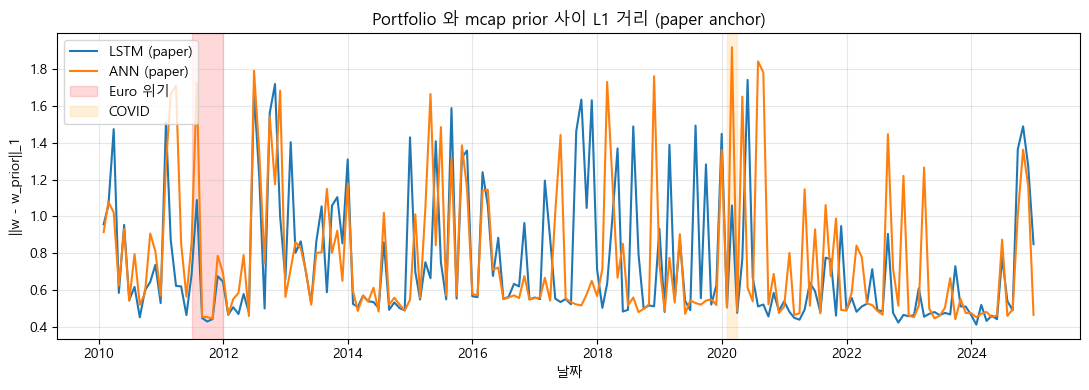

In [ ]:
# -- L17. Portfolio weight 와 mcap prior 사이 L1 거리 --
import pickle
CUTOFF = '2023-12-31'  # 평가 컷오프

panel = pd.read_csv(Path.cwd() / 'data' / 'monthly_panel.csv',
                    usecols=['date','ticker','log_mcap'], parse_dates=['date'])
panel = panel.set_index(['date','ticker'])

mcap_panel = np.exp(panel['log_mcap']).unstack('ticker')
prior_panel = mcap_panel.div(mcap_panel.sum(axis=1), axis=0)

def _dist_to_prior(name):
    p = RESULTS_DIR / f'{name}.pkl'
    if not p.exists(): return None
    with open(p, 'rb') as f:
        w = pickle.load(f)['weights']
    common_dates = w.index.intersection(prior_panel.index)
    common_tix   = w.columns.intersection(prior_panel.columns)
    w_aligned     = w.loc[common_dates, common_tix].fillna(0)
    prior_aligned = prior_panel.loc[common_dates, common_tix].fillna(0)
    return (w_aligned - prior_aligned).abs().sum(axis=1)

COMPARE = [
    ('paper_lstm',           'paper_ann',                'paper anchor'),
    ('mat_mcap_eq_fpm_pap',  'mat_mcap_eq_fpm_pap_ann',  'P=eq, Q=fpm'),
    ('mat_mcap_rp_fpm_pap',  'mat_mcap_rp_fpm_pap_ann',  'P=rp, Q=fpm'),
]
REGIMES_L17 = [
    ('R1_회복', '2010-01-01', '2012-06-30'),
    ('R2_확장', '2012-07-01', '2019-12-31'),
    ('R3_변동', '2020-01-01', '2024-12-31'),
]

print('=' * 84)
print(f'{"":<14}{"LSTM 거리":>14s}{"ANN 거리":>14s}{"차이 (L-A)":>14s}{"prior 추종":>16s}')
print(f'{"config":<14}{"(평균)":>14s}{"(평균)":>14s}{"":>14s}{"강한 쪽":>16s}')
print('-' * 84)

for L_name, A_name, label in COMPARE:
    dL = _dist_to_prior(L_name); dA = _dist_to_prior(A_name)
    if dL is None or dA is None:
        print(f'\n[{label}]  (pkl 없음)')
        continue
    print(f'\n[{label}]')
    for lbl, s, e in REGIMES_L17:
        sub_L = dL[(dL.index >= s) & (dL.index <= e)]
        sub_A = dA[(dA.index >= s) & (dA.index <= e)]
        diff = sub_L.mean() - sub_A.mean()
        winner = 'ANN' if diff > 0 else 'LSTM'
        print(f'  {lbl:<10}  {sub_L.mean():>12.3f}  {sub_A.mean():>12.3f}  {diff:>+12.3f}  {winner:>14s}')
    print(f'  {"전체":<10}  {dL.mean():>12.3f}  {dA.mean():>12.3f}  {dL.mean()-dA.mean():>+12.3f}  '
          f'{"ANN" if dL.mean()>dA.mean() else "LSTM":>14s}')

print()
fig, ax = plt.subplots(figsize=(11, 4))
dL = _dist_to_prior('paper_lstm')
dA = _dist_to_prior('paper_ann')
if dL is not None and dA is not None:
    ax.plot(dL.index, dL.values, label='LSTM (paper)', color='C0', lw=1.5)
    ax.plot(dA.index, dA.values, label='ANN (paper)',  color='C1', lw=1.5)
    ax.axvspan(pd.Timestamp('2011-07-01'), pd.Timestamp('2012-01-01'), alpha=0.15, color='red', label='Euro 위기')
    ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01'), alpha=0.15, color='orange', label='COVID')
    ax.set_title('Portfolio 와 mcap prior 사이 L1 거리 (paper anchor)')
    ax.set_ylabel('||w - w_prior||_1')
    ax.set_xlabel('날짜')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## L18. Q 값 시계열 / 분포 by 레짐

**검증**: LSTM Q (paper_lstm) 가 ANN Q (paper_ann) 보다 음수 더 많고 절대값 크면 → low-vol 알파 안 잡히는 시기에 LSTM이 더 strong negative bet → R1·R3에서 손실 큼.

각 pkl `meta['Q']` 컬럼 사용.

레짐                      평균 Q        표준편차       음수 비율      |Q| 평균
--------------------------------------------------------------------------------

[R1_회복]
  LSTM          +0.00012     0.00204       43.3%     0.00159
  ANN           +0.00194     0.00136       10.0%     0.00203

[R2_확장]
  LSTM          -0.00105     0.00366       60.0%     0.00290
  ANN           -0.00021     0.00334       54.4%     0.00256

[R3_변동]
  LSTM          -0.00276     0.00652       68.3%     0.00474
  ANN           -0.00193     0.00661       56.7%     0.00478

[전체]
  LSTM          -0.00142     0.00473       60.0%     0.00329
  ANN           -0.00042     0.00469       47.8%     0.00322


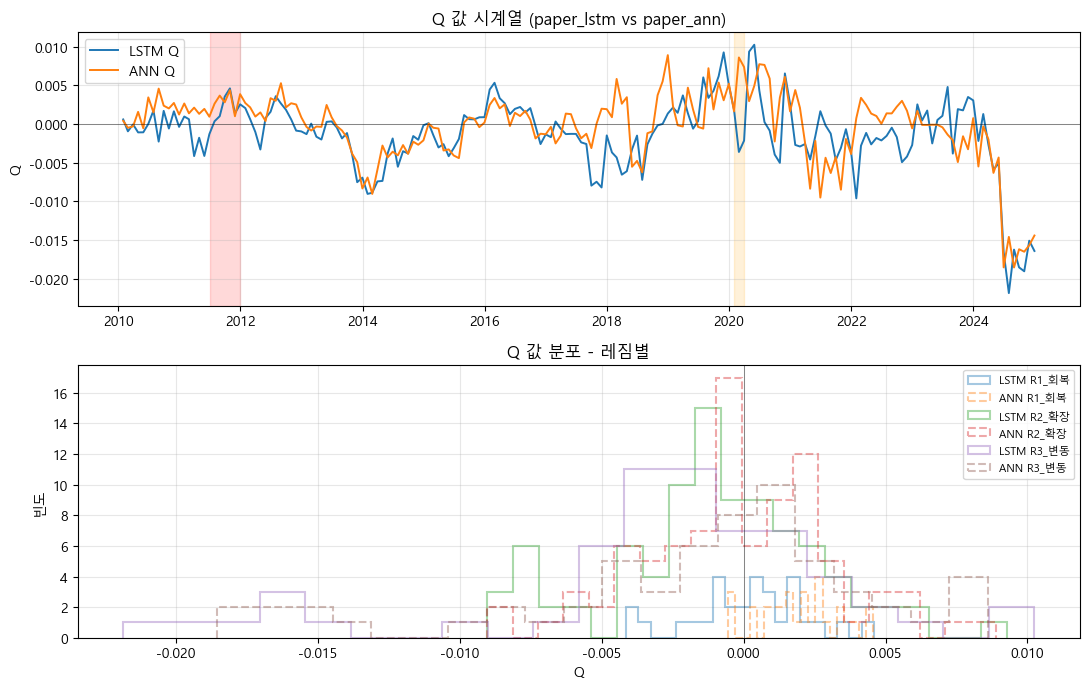

In [ ]:
# -- L18. Q 시계열 + 레짐별 분포 (paper anchor) --
import pickle
CUTOFF = '2023-12-31'  # 평가 컷오프

def _get_Q(name):
    p = RESULTS_DIR / f'{name}.pkl'
    if not p.exists(): return None
    with open(p, 'rb') as f:
        meta = pickle.load(f)['meta']
    return meta['Q']

QL = _get_Q('paper_lstm')
QA = _get_Q('paper_ann')

REGIMES_L18 = [
    ('R1_회복', '2010-01-01', '2012-06-30'),
    ('R2_확장', '2012-07-01', '2019-12-31'),
    ('R3_변동', '2020-01-01', '2024-12-31'),
]

print('=' * 80)
print(f'{"레짐":<10s}{"":<6s}{"평균 Q":>12s}{"표준편차":>12s}{"음수 비율":>12s}{"|Q| 평균":>12s}')
print('-' * 80)
for lbl, s, e in REGIMES_L18:
    qL = QL[(QL.index >= s) & (QL.index <= e)]
    qA = QA[(QA.index >= s) & (QA.index <= e)]
    print(f'\n[{lbl}]')
    print(f'  {"LSTM":<10s}  {qL.mean():>+10.5f}  {qL.std():>10.5f}  {(qL<0).mean():>10.1%}  {qL.abs().mean():>10.5f}')
    print(f'  {"ANN":<10s}  {qA.mean():>+10.5f}  {qA.std():>10.5f}  {(qA<0).mean():>10.1%}  {qA.abs().mean():>10.5f}')

print()
print(f'[전체]')
print(f'  {"LSTM":<10s}  {QL.mean():>+10.5f}  {QL.std():>10.5f}  {(QL<0).mean():>10.1%}  {QL.abs().mean():>10.5f}')
print(f'  {"ANN":<10s}  {QA.mean():>+10.5f}  {QA.std():>10.5f}  {(QA<0).mean():>10.1%}  {QA.abs().mean():>10.5f}')
print('=' * 80)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)

ax = axes[0]
ax.plot(QL.index, QL.values, label='LSTM Q', color='C0', lw=1.4)
ax.plot(QA.index, QA.values, label='ANN Q',  color='C1', lw=1.4)
ax.axhline(0, color='k', lw=0.6, alpha=0.5)
ax.axvspan(pd.Timestamp('2011-07-01'), pd.Timestamp('2012-01-01'), alpha=0.15, color='red')
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01'), alpha=0.15, color='orange')
ax.set_title('Q 값 시계열 (paper_lstm vs paper_ann)')
ax.set_ylabel('Q')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)

ax = axes[1]
for lbl, s, e in REGIMES_L18:
    qL = QL[(QL.index >= s) & (QL.index <= e)]
    qA = QA[(QA.index >= s) & (QA.index <= e)]
    ax.hist(qL.values, bins=20, alpha=0.4, label=f'LSTM {lbl}', histtype='step', lw=1.5)
    ax.hist(qA.values, bins=20, alpha=0.4, label=f'ANN {lbl}',  histtype='step', lw=1.5, ls='--')
ax.axvline(0, color='k', lw=0.6, alpha=0.5)
ax.set_title('Q 값 분포 - 레짐별')
ax.set_xlabel('Q'); ax.set_ylabel('빈도')
ax.legend(loc='upper right', fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## L20. p_w=eq 매트릭스 — prior x q (LSTM vs ANN)

**고정**: p_weight=eq, omega=ff3_paper
**변경**: prior in {mcap, eq, rp} x q in {fix, lam, raw, inv, vsp, fpm} = 18 pair

각 pair: Sharpe (LSTM, ANN, 차이) + 레짐별 차이 + Sortino 차이.

In [ ]:
# -- L20: p_w=eq 매트릭스 prior x q (LSTM vs ANN) --
import pickle
from master_table import REGIMES as _REGIMES_orig
REGIMES = [(lbl, s, '2023-12-31' if lbl == 'R3_변동' else e) for lbl, s, e in _REGIMES_orig]
CUTOFF = '2023-12-31'  # 평가 컷오프

P_W = "eq"

def _sh(name, s=None, e=None):
    p = RESULTS_DIR / f"{name}.pkl"
    if not p.exists(): return None
    with open(p, "rb") as f:
        r = pickle.load(f)["ret"].dropna()
    if s is not None:
        r = r[(r.index >= s) & (r.index <= e)]
    if len(r) < 6: return None
    rfa = rf.reindex(r.index).fillna(0)
    exc = r - rfa
    vol = r.std() * np.sqrt(12)
    return float(exc.mean() * 12 / vol) if vol > 0 else np.nan

def _so(name):
    p = RESULTS_DIR / f"{name}.pkl"
    if not p.exists(): return None
    with open(p, "rb") as f:
        r = pickle.load(f)["ret"].dropna()
    rfa = rf.reindex(r.index).fillna(0)
    exc = r - rfa
    dn = r[r < 0].std() * np.sqrt(12)
    return float(exc.mean() * 12 / dn) if (dn and dn > 0) else np.nan

PAIRS = []
for pr in ["mcap", "eq", "rp"]:
    for q in ["fix", "lam", "raw", "inv", "vsp", "fpm"]:
        if pr == "mcap" and q == "fpm" and P_W == "mcap":
            L_name, A_name = "paper_lstm", "paper_ann"
        elif pr == "mcap" and q == "fpm":
            L_name = f"mat_mcap_{P_W}_fpm_pap"
            A_name = f"mat_mcap_{P_W}_fpm_pap_ann"
        else:
            L_name = f"mat_{pr}_{P_W}_{q}_pap"
            A_name = f"mat_{pr}_{P_W}_{q}_pap_ann"
        PAIRS.append((pr, q, L_name, A_name))

rows = []
for pr, q, L, A in PAIRS:
    full_L = _sh(L); full_A = _sh(A)
    if full_L is None or full_A is None:
        rows.append({"prior": pr, "q": q, "L_Sh": np.nan, "A_Sh": np.nan, "d_Sh": np.nan,
                     "R1_d": np.nan, "R2_d": np.nan, "R3_d": np.nan,
                     "d_So": np.nan, "win": "?"})
        continue
    so_L = _so(L); so_A = _so(A)
    R = {}
    for lbl, s, e in REGIMES:
        sL = _sh(L, s, e); sA = _sh(A, s, e)
        R[lbl] = (sL - sA) if (sL is not None and sA is not None) else np.nan
    rows.append({
        "prior": pr, "q": q,
        "L_Sh": full_L, "A_Sh": full_A, "d_Sh": full_L - full_A,
        "R1_d": R["R1_회복"], "R2_d": R["R2_확장"], "R3_d": R["R3_변동"],
        "d_So": (so_L - so_A) if (so_L is not None and so_A is not None) else np.nan,
        "win": "L" if full_L > full_A else "A",
    })

df = pd.DataFrame(rows)

# 요약
print("=" * 78)
sub = df.dropna(subset=["d_Sh"])
n = len(sub); wL = (sub["win"] == "L").sum()
print(f"  [p_w={P_W}] 전체 기간: LSTM {wL}/{n} 승,  평균 d_Sharpe={sub['d_Sh'].mean():+.4f}")
for lbl, col in [("R1_회복","R1_d"), ("R2_확장","R2_d"), ("R3_변동","R3_d")]:
    sub_r = df.dropna(subset=[col])
    wL_r = (sub_r[col] > 0).sum()
    print(f"  [p_w={P_W}] {lbl}: LSTM {wL_r}/{len(sub_r)} 승,  평균 d_Sharpe={sub_r[col].mean():+.4f}")
print("=" * 78)

display_df = df.set_index(["prior","q"])[[
    "L_Sh","A_Sh","d_Sh","R1_d","R2_d","R3_d","d_So","win",
]]
display_df.columns = [
    "LSTM Sh","ANN Sh","Δ Sh (전체)",
    "Δ Sh (R1)","Δ Sh (R2)","Δ Sh (R3)",
    "Δ So (전체)","win",
]

def _hl(v):
    if not isinstance(v, (int, float)) or pd.isna(v): return ""
    if v > 0: return "background-color: #b8e0b8; color: black; font-weight: bold"
    if v < 0: return "background-color: #f4b6b6; color: black; font-weight: bold"
    return ""

styled = display_df.style.format({
    "LSTM Sh":"{:.3f}","ANN Sh":"{:.3f}",
    "Δ Sh (전체)":"{:+.3f}","Δ Sh (R1)":"{:+.3f}",
    "Δ Sh (R2)":"{:+.3f}","Δ Sh (R3)":"{:+.3f}",
    "Δ So (전체)":"{:+.3f}",
}).map(_hl, subset=["Δ Sh (전체)","Δ Sh (R1)","Δ Sh (R2)","Δ Sh (R3)","Δ So (전체)"])

display(styled)


  [p_w=eq] 전체 기간: LSTM 18/18 승,  평균 d_Sharpe=+0.0851
  [p_w=eq] R1_회복: LSTM 3/18 승,  평균 d_Sharpe=-0.0277
  [p_w=eq] R2_확장: LSTM 18/18 승,  평균 d_Sharpe=+0.0777
  [p_w=eq] R3_변동: LSTM 18/18 승,  평균 d_Sharpe=+0.1530


## L21. p_w=rp 매트릭스 — prior x q (LSTM vs ANN)

**고정**: p_weight=rp, omega=ff3_paper
**변경**: prior in {mcap, eq, rp} x q in {fix, lam, raw, inv, vsp, fpm} = 18 pair

각 pair: Sharpe (LSTM, ANN, 차이) + 레짐별 차이 + Sortino 차이.

In [ ]:
# -- L21: p_w=rp 매트릭스 prior x q (LSTM vs ANN) --
import pickle
from master_table import REGIMES as _REGIMES_orig
REGIMES = [(lbl, s, '2023-12-31' if lbl == 'R3_변동' else e) for lbl, s, e in _REGIMES_orig]
CUTOFF = '2023-12-31'  # 평가 컷오프

P_W = "rp"

def _sh(name, s=None, e=None):
    p = RESULTS_DIR / f"{name}.pkl"
    if not p.exists(): return None
    with open(p, "rb") as f:
        r = pickle.load(f)["ret"].dropna()
    if s is not None:
        r = r[(r.index >= s) & (r.index <= e)]
    if len(r) < 6: return None
    rfa = rf.reindex(r.index).fillna(0)
    exc = r - rfa
    vol = r.std() * np.sqrt(12)
    return float(exc.mean() * 12 / vol) if vol > 0 else np.nan

def _so(name):
    p = RESULTS_DIR / f"{name}.pkl"
    if not p.exists(): return None
    with open(p, "rb") as f:
        r = pickle.load(f)["ret"].dropna()
    rfa = rf.reindex(r.index).fillna(0)
    exc = r - rfa
    dn = r[r < 0].std() * np.sqrt(12)
    return float(exc.mean() * 12 / dn) if (dn and dn > 0) else np.nan

PAIRS = []
for pr in ["mcap", "eq", "rp"]:
    for q in ["fix", "lam", "raw", "inv", "vsp", "fpm"]:
        if pr == "mcap" and q == "fpm" and P_W == "mcap":
            L_name, A_name = "paper_lstm", "paper_ann"
        elif pr == "mcap" and q == "fpm":
            L_name = f"mat_mcap_{P_W}_fpm_pap"
            A_name = f"mat_mcap_{P_W}_fpm_pap_ann"
        else:
            L_name = f"mat_{pr}_{P_W}_{q}_pap"
            A_name = f"mat_{pr}_{P_W}_{q}_pap_ann"
        PAIRS.append((pr, q, L_name, A_name))

rows = []
for pr, q, L, A in PAIRS:
    full_L = _sh(L); full_A = _sh(A)
    if full_L is None or full_A is None:
        rows.append({"prior": pr, "q": q, "L_Sh": np.nan, "A_Sh": np.nan, "d_Sh": np.nan,
                     "R1_d": np.nan, "R2_d": np.nan, "R3_d": np.nan,
                     "d_So": np.nan, "win": "?"})
        continue
    so_L = _so(L); so_A = _so(A)
    R = {}
    for lbl, s, e in REGIMES:
        sL = _sh(L, s, e); sA = _sh(A, s, e)
        R[lbl] = (sL - sA) if (sL is not None and sA is not None) else np.nan
    rows.append({
        "prior": pr, "q": q,
        "L_Sh": full_L, "A_Sh": full_A, "d_Sh": full_L - full_A,
        "R1_d": R["R1_회복"], "R2_d": R["R2_확장"], "R3_d": R["R3_변동"],
        "d_So": (so_L - so_A) if (so_L is not None and so_A is not None) else np.nan,
        "win": "L" if full_L > full_A else "A",
    })

df = pd.DataFrame(rows)

# 요약
print("=" * 78)
sub = df.dropna(subset=["d_Sh"])
n = len(sub); wL = (sub["win"] == "L").sum()
print(f"  [p_w={P_W}] 전체 기간: LSTM {wL}/{n} 승,  평균 d_Sharpe={sub['d_Sh'].mean():+.4f}")
for lbl, col in [("R1_회복","R1_d"), ("R2_확장","R2_d"), ("R3_변동","R3_d")]:
    sub_r = df.dropna(subset=[col])
    wL_r = (sub_r[col] > 0).sum()
    print(f"  [p_w={P_W}] {lbl}: LSTM {wL_r}/{len(sub_r)} 승,  평균 d_Sharpe={sub_r[col].mean():+.4f}")
print("=" * 78)

display_df = df.set_index(["prior","q"])[[
    "L_Sh","A_Sh","d_Sh","R1_d","R2_d","R3_d","d_So","win",
]]
display_df.columns = [
    "LSTM Sh","ANN Sh","Δ Sh (전체)",
    "Δ Sh (R1)","Δ Sh (R2)","Δ Sh (R3)",
    "Δ So (전체)","win",
]

def _hl(v):
    if not isinstance(v, (int, float)) or pd.isna(v): return ""
    if v > 0: return "background-color: #b8e0b8; color: black; font-weight: bold"
    if v < 0: return "background-color: #f4b6b6; color: black; font-weight: bold"
    return ""

styled = display_df.style.format({
    "LSTM Sh":"{:.3f}","ANN Sh":"{:.3f}",
    "Δ Sh (전체)":"{:+.3f}","Δ Sh (R1)":"{:+.3f}",
    "Δ Sh (R2)":"{:+.3f}","Δ Sh (R3)":"{:+.3f}",
    "Δ So (전체)":"{:+.3f}",
}).map(_hl, subset=["Δ Sh (전체)","Δ Sh (R1)","Δ Sh (R2)","Δ Sh (R3)","Δ So (전체)"])

display(styled)


  [p_w=rp] 전체 기간: LSTM 18/18 승,  평균 d_Sharpe=+0.0878
  [p_w=rp] R1_회복: LSTM 18/18 승,  평균 d_Sharpe=+0.1415
  [p_w=rp] R2_확장: LSTM 18/18 승,  평균 d_Sharpe=+0.0773
  [p_w=rp] R3_변동: LSTM 18/18 승,  평균 d_Sharpe=+0.0646
